In [1]:

# ── Dependencies ──────────────────────────────────────────────────────────────
import sys, os, glob, torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from collections import defaultdict
from scipy.spatial import KDTree
from torch import nn
from torch_geometric.data import Data
from torch_geometric.nn import MessagePassing
from torch_geometric.loader import DataLoader
from torch_geometric.utils import softmax as pyg_softmax
from torch.utils.data import Dataset

# ── Constants (must match model.ipynb) ────────────────────────────────────────
CHUNK_GLOB = 'data/gemmi_atom14/chunk_*.parquet'
CACHE_DIR  = 'data/pt_cache_v3'
CHECKPOINT = 'data/best_model_v7_sm_softmax.pt'

RESIDUES   = ['ALA','ARG','ASN','ASP','CYS','GLN','GLU','GLY',
              'HIS','ILE','LEU','LYS','MET','PHE','PRO','SER',
              'THR','TRP','TYR','VAL','UNK']
RES_TO_IDX = {r: i for i, r in enumerate(RESIDUES)}
IDX_TO_RES = {i: r for r, i in RES_TO_IDX.items()}
METAL_BINDERS = {'HIS', 'CYS', 'ASP', 'GLU'}

_ATOM14_COLS = [f'{c}{i}' for i in range(14) for c in ('x', 'y', 'z')]

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# ── Model classes (copied from model.ipynb) ────────────────────────────────────
def _compute_distal(coords14_raw):
    finite_mask = np.isfinite(coords14_raw).all(axis=2)
    last_idx    = (finite_mask * np.arange(14)).argmax(axis=1)
    last_idx[~finite_mask.any(axis=1)] = 1
    return coords14_raw[np.arange(len(coords14_raw)), last_idx, :]

class MetalBindingDataset(Dataset):
    def __init__(self, chunk_glob, structure_ids, k=10, cache_dir=CACHE_DIR):
        self.k = k; self.ids = list(structure_ids); self.cache_dir = cache_dir
        self.index = {}
        for fpath in glob.glob(chunk_glob):
            df = pd.read_parquet(fpath, columns=['structure_id'])
            for sid in df['structure_id'].unique():
                self.index[sid] = fpath
    def __len__(self): return len(self.ids)
    def _attach_distal(self, d, sid):
        if hasattr(d, 'pos_distal'): return d
        d.pos_distal = d.pos; return d
    def __getitem__(self, idx):
        sid = self.ids[idx]
        path = os.path.join(self.cache_dir, f'{sid}.pt')
        if os.path.exists(path):
            d = torch.load(path, weights_only=False)
            if not hasattr(d, 'num_metals'): d.num_metals = d.y.shape[0]
            return self._attach_distal(d, sid)
        raise FileNotFoundError(sid)

class MLP(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, out_dim), nn.ReLU(), nn.Linear(out_dim, out_dim))
    def forward(self, x): return self.net(x)

class MetalMPNNLayer(MessagePassing):
    def __init__(self, node_dim, edge_dim, hidden_dim):
        super().__init__(aggr='sum')
        self.message_mlp = MLP(2*node_dim+edge_dim, hidden_dim)
        self.update_mlp  = MLP(node_dim+hidden_dim, node_dim)
    def forward(self, x, edge_index, edge_attr):
        msg = self.propagate(edge_index, x=x, edge_attr=edge_attr)
        return self.update_mlp(torch.cat([x, msg], dim=-1))
    def message(self, x_i, x_j, edge_attr):
        return self.message_mlp(torch.cat([x_i, x_j, edge_attr], dim=-1))

class MetalPredictionHead(nn.Module):
    def __init__(self, node_dim, attn_mode='softmax', top_k=10, res_emb_dim=16,
                 temperature=1.0, learn_temperature=False):
        super().__init__()
        self.attn_mode = attn_mode; self.top_k = top_k; self.res_emb_dim = res_emb_dim
        log_tau = torch.tensor(float(temperature)).log()
        if learn_temperature: self.log_temperature = nn.Parameter(log_tau)
        else: self.register_buffer('log_temperature', log_tau)
        if res_emb_dim > 0: self.res_bypass = nn.Embedding(len(RESIDUES), res_emb_dim)
        attn_in_dim = node_dim + res_emb_dim
        self.attention_mlp = nn.Sequential(nn.Linear(attn_in_dim, attn_in_dim//2), nn.ReLU(),
                                           nn.Linear(attn_in_dim//2, 1))
    def forward(self, x, pos, pos_distal, batch, res_type, return_attn=False):
        num_graphs = batch.max().item() + 1
        counts = torch.zeros(num_graphs, dtype=torch.float, device=x.device) \
                      .scatter_add(0, batch, torch.ones(batch.shape[0], dtype=torch.float, device=x.device))
        centroid = torch.zeros(num_graphs, 3, device=x.device)
        centroid.scatter_add_(0, batch.unsqueeze(1).expand(-1, 3), pos)
        centroid /= counts.unsqueeze(1)
        centered_distal = pos_distal - centroid[batch]
        attn_input = torch.cat([x, self.res_bypass(res_type)], dim=-1) if self.res_emb_dim > 0 else x
        attn_logits = self.attention_mlp(attn_input) / self.log_temperature.exp()
        attn_weights = pyg_softmax(attn_logits, batch, dim=0)
        offset = torch.zeros(num_graphs, 3, device=x.device)
        offset.scatter_add_(0, batch.unsqueeze(1).expand(-1, 3), attn_weights * centered_distal)
        if return_attn: return centroid + offset, attn_weights.squeeze(1)
        return centroid + offset

class MetalPredictionModel(nn.Module):
    def __init__(self, input_dim=42, node_dim=64, edge_dim=4, hidden_dim=64,
                 attn_mode='softmax', top_k=10, res_emb_dim=16,
                 temperature=1.0, learn_temperature=False):
        super().__init__()
        self.res_embedding = nn.Embedding(len(RESIDUES), node_dim)
        self.node_embed    = nn.Linear(input_dim, node_dim)
        self.layers = nn.ModuleList([MetalMPNNLayer(node_dim, edge_dim, hidden_dim) for _ in range(3)])
        self.head   = MetalPredictionHead(node_dim, attn_mode=attn_mode, top_k=top_k,
                                          res_emb_dim=res_emb_dim, temperature=temperature,
                                          learn_temperature=learn_temperature)
    def forward(self, x, edge_index, edge_attr, batch, res_type, pos, pos_distal, return_attn=False):
        x = self.node_embed(x) + self.res_embedding(res_type)
        for layer in self.layers: x = layer(x, edge_index, edge_attr)
        return self.head(x, pos, pos_distal, batch, res_type, return_attn=return_attn)

print('Classes defined. Device:', device)


Classes defined. Device: mps


/Users/stewartgreen/CODE/CS540/Final Project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Load model + evaluate test structures ─────────────────────────────────────
# Load the cluster-aware test split (same seed as model.ipynb)
df_ids = pd.read_parquet('data/clusters/clusters.parquet', columns=['structure_id', 'cluster_id'])
cluster_to_structures = df_ids.drop_duplicates().groupby('cluster_id')['structure_id'].apply(list).to_dict()
clusters = list(cluster_to_structures.keys())
rng = np.random.default_rng(42)
rng.shuffle(clusters)
n = len(clusters)
single_metal_set = set()
for sid, path in [(os.path.basename(f).replace('.pt',''), f)
                  for f in glob.glob(f'{CACHE_DIR}/*.pt')]:
    try:
        d = torch.load(path, weights_only=False)
        if d.y.shape[0] == 1:
            single_metal_set.add(sid)
    except Exception:
        pass

sm_cluster_to_structs = {c: [s for s in structs if s in single_metal_set]
                          for c, structs in cluster_to_structures.items()}
sm_cluster_to_structs = {c: s for c, s in sm_cluster_to_structs.items() if s}
sm_clusters = list(sm_cluster_to_structs.keys())
rng2 = np.random.default_rng(42)
rng2.shuffle(sm_clusters)
n2 = len(sm_clusters)
sm_test_ids = [s for c in sm_clusters[int(0.9*n2):] for s in sm_cluster_to_structs[c]]
print(f'Test structures: {len(sm_test_ids)}')

# Load model — try learn_temperature=True first (new checkpoint), fall back to False
model = MetalPredictionModel(learn_temperature=True).to(device)
try:
    model.load_state_dict(torch.load(CHECKPOINT, weights_only=True))
    print('Loaded with learn_temperature=True')
except RuntimeError:
    model = MetalPredictionModel(learn_temperature=False).to(device)
    model.load_state_dict(torch.load(CHECKPOINT, weights_only=True))
    print('Loaded with learn_temperature=False')
model.eval()

# Evaluate up to 400 test structures, collect per-structure results
test_ds     = MetalBindingDataset(CHUNK_GLOB, sm_test_ids[:400])
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=0)

records = []   # (sid_idx, naive_err, model_err, pred_coords, true_coords, attn_weights, ca_pos, res_types)
sid_cursor = 0

with torch.no_grad():
    for batch in test_loader:
        batch_size = batch.batch.max().item() + 1
        batch = batch.to(device)

        num_graphs = batch.batch.max().item() + 1
        counts = torch.zeros(num_graphs, dtype=torch.float, device=device) \
                      .scatter_add(0, batch.batch, torch.ones(batch.batch.shape[0], dtype=torch.float, device=device))
        centroid = torch.zeros(num_graphs, 3, device=device)
        centroid.scatter_add_(0, batch.batch.unsqueeze(1).expand(-1, 3), batch.pos)
        centroid /= counts.unsqueeze(1)

        pred, attn = model(batch.x, batch.edge_index, batch.edge_attr,
                           batch.batch, batch.res_type, batch.pos, batch.pos_distal,
                           return_attn=True)

        for i in range(num_graphs):
            mask      = batch.batch == i
            true_c    = batch.y[i].cpu()
            pred_c    = pred[i].cpu()
            naive_err = (centroid[i].cpu() - true_c).norm().item()
            model_err = (pred_c - true_c).norm().item()
            records.append({
                'sid':       sm_test_ids[sid_cursor],
                'naive_err': naive_err,
                'model_err': model_err,
                'pred':      pred_c.numpy(),
                'true':      true_c.numpy(),
                'attn':      attn[mask].cpu().numpy(),
                'ca':        batch.pos[mask].cpu().numpy(),
                'res_type':  batch.res_type[mask].cpu().numpy(),
            })
            sid_cursor += 1

print(f'Evaluated {len(records)} structures')
naive_errs = np.array([r['naive_err'] for r in records])
model_errs = np.array([r['model_err'] for r in records])
deltas     = model_errs - naive_errs

print(f'Model mean error: {model_errs.mean():.2f} Å  |  Naive mean: {naive_errs.mean():.2f} Å')
print(f'Model beats naive in {(deltas < 0).sum()}/{len(records)} structures')


FileNotFoundError: [Errno 2] No such file or directory: 'data/clusters/clusters.parquet'

Selected structures:
  Best prediction  1EP2.cif  naive=2.3Å  model=0.8Å  delta=-1.4Å
  Best recovery    1VK6.cif  naive=30.2Å  model=21.6Å  delta=-8.5Å
  Worst failure    1KXP.cif  naive=20.9Å  model=27.5Å  delta=+6.5Å


/var/folders/4m/hw_p_db57s56c9jqdpbjczfh0000gn/T/ipykernel_9306/2099529165.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  return cm.get_cmap(cmap)(norm(weights))   # (N, 4)


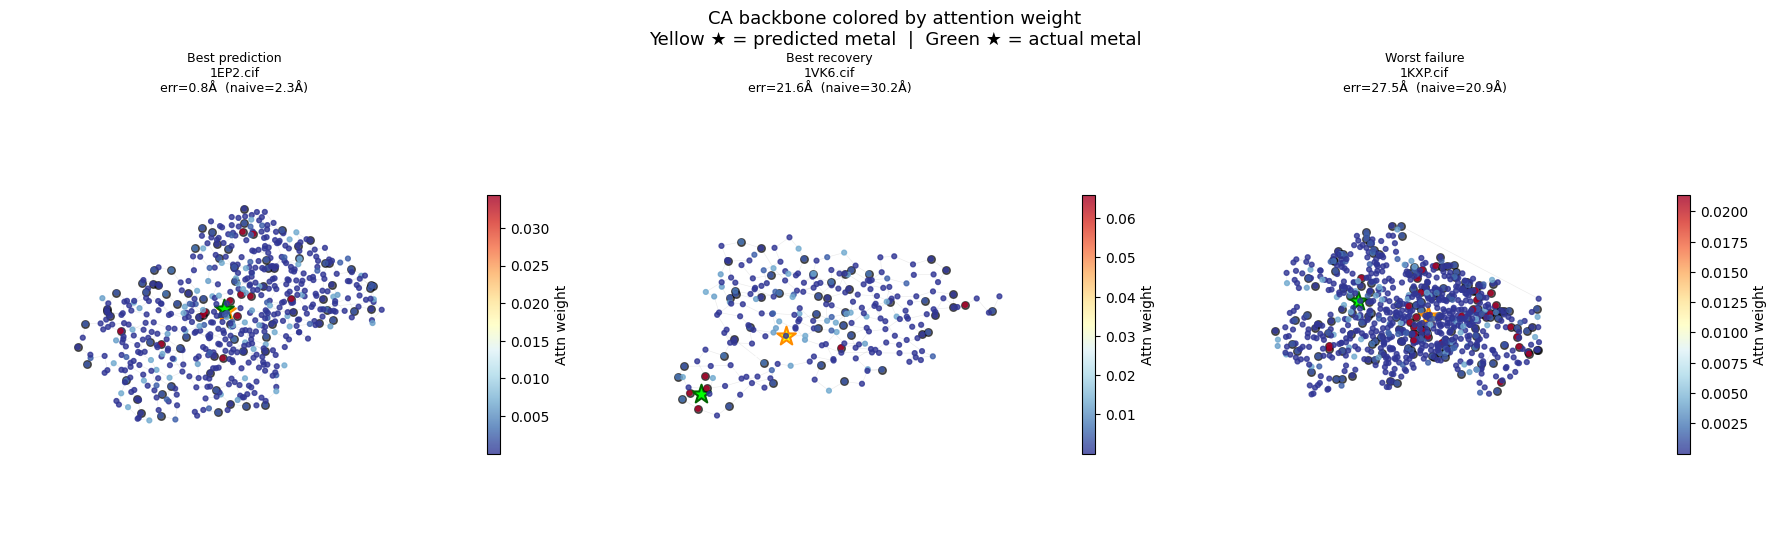

Saved: data/viz_3d_backbone.png


In [ ]:
# ── Viz 1 & 2: 3D CA backbone + attention coloring ───────────────────────────
# Pick 3 interesting structures: best model win, best model recovery, worst failure
best_win      = records[np.argmin(model_errs)]
best_recovery = records[np.argmin(deltas)]   # biggest (naive_err - model_err)
worst_failure = records[np.argmax(deltas)]   # biggest (model_err - naive_err)

print('Selected structures:')
for label, r in [('Best prediction', best_win),
                 ('Best recovery  ', best_recovery),
                 ('Worst failure  ', worst_failure)]:
    print(f'  {label}  {r["sid"]}  naive={r["naive_err"]:.1f}Å  model={r["model_err"]:.1f}Å  '
          f'delta={r["model_err"]-r["naive_err"]:+.1f}Å')

# ── Helper: weight → hex color (blue=low, red=high) ─────────────────────────
def weights_to_rgba(weights, cmap='RdYlBu_r'):
    norm = mcolors.Normalize(vmin=weights.min(), vmax=weights.max())
    return cm.get_cmap(cmap)(norm(weights))   # (N, 4)

# ── Plot: 3 structures side by side ──────────────────────────────────────────
cases = [('Best prediction', best_win),
         ('Best recovery',   best_recovery),
         ('Worst failure',   worst_failure)]

fig = plt.figure(figsize=(18, 6))
fig.suptitle('CA backbone colored by attention weight\nYellow ★ = predicted metal  |  Green ★ = actual metal',
             fontsize=13)

for col, (label, r) in enumerate(cases):
    ax = fig.add_subplot(1, 3, col+1, projection='3d')
    ca     = r['ca']         # (N, 3)
    attn   = r['attn']       # (N,)
    pred   = r['pred']       # (3,)
    true   = r['true']       # (3,)
    rtypes = r['res_type']   # (N,)

    colors = weights_to_rgba(attn)

    # Backbone trace (thin gray line through CA positions)
    ax.plot(ca[:, 0], ca[:, 1], ca[:, 2], color='lightgray', lw=0.4, alpha=0.5, zorder=1)

    # Scatter CA positions colored by attention
    sc = ax.scatter(ca[:, 0], ca[:, 1], ca[:, 2],
                    c=attn, cmap='RdYlBu_r', s=12, alpha=0.8, zorder=2,
                    vmin=attn.min(), vmax=attn.max())

    # Highlight metal-binding residue types
    for res_idx in np.where([IDX_TO_RES[i] in METAL_BINDERS for i in rtypes])[0]:
        ax.scatter(*ca[res_idx], c='black', s=30, marker='o', zorder=3, alpha=0.6)

    # Predicted and actual metal positions
    ax.scatter(*pred, c='yellow', s=200, marker='*', edgecolors='darkorange',
               linewidths=1.5, zorder=5, label='Predicted')
    ax.scatter(*true, c='lime',   s=200, marker='*', edgecolors='darkgreen',
               linewidths=1.5, zorder=5, label='Actual')

    # Line connecting predicted to actual
    ax.plot([pred[0], true[0]], [pred[1], true[1]], [pred[2], true[2]],
            color='white', lw=1.5, linestyle='--', alpha=0.8, zorder=4)

    ax.set_title(f'{label}\n{r["sid"]}\nerr={r["model_err"]:.1f}Å  (naive={r["naive_err"]:.1f}Å)',
                 fontsize=9)
    ax.set_axis_off()
    plt.colorbar(sc, ax=ax, shrink=0.5, pad=0.05, label='Attn weight')

plt.tight_layout()
plt.savefig('data/viz_3d_backbone.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/viz_3d_backbone.png')


In [ ]:
# ── Viz 2 (enhanced): py3Dmol full-protein attention coloring ─────────────────
# Requires: pip install py3Dmol
# Uses the actual CIF file to render cartoon + per-residue attention color.
try:
    import py3Dmol

    def attn_view(record, width=800, height=500):
        sid    = record['sid']
        ca     = record['ca']
        attn   = record['attn']
        pred   = record['pred']
        true_c = record['true']

        # Read per-residue metadata from parquet to get chain + res_num
        fpath = None
        for fp in glob.glob(CHUNK_GLOB):
            df_idx = pd.read_parquet(fp, columns=['structure_id'])
            if sid in df_idx['structure_id'].values:
                fpath = fp; break

        if fpath is None:
            print(f'Parquet not found for {sid}'); return

        df = pd.read_parquet(fpath)
        df = df[(df['structure_id'] == sid) & (~df['is_metal'])].reset_index(drop=True)
        ca_ok = np.isfinite(df[['x1','y1','z1']].values).all(axis=1)
        df = df[ca_ok].reset_index(drop=True)

        # Clip to same length as attn (CA-valid rows)
        n = min(len(df), len(attn))
        df = df.iloc[:n]
        attn_clipped = attn[:n]

        # Map attention to hex colors (blue → red)
        norm  = mcolors.Normalize(vmin=attn_clipped.min(), vmax=attn_clipped.max())
        cmap  = cm.get_cmap('RdYlBu_r')

        def to_hex(w):
            return mcolors.to_hex(cmap(norm(w)))

        # Load CIF into py3Dmol
        cif_path = f'data/cifs/{sid}'
        if not os.path.exists(cif_path):
            print(f'CIF not found: {cif_path}'); return
        with open(cif_path) as f:
            cif_data = f.read()

        view = py3Dmol.view(width=width, height=height)
        view.addModel(cif_data, 'cif')
        view.setStyle({}, {'cartoon': {'color': '#cccccc', 'opacity': 0.3}})

        # Color each residue by attention weight
        for _, row in df.iterrows():
            color = to_hex(attn_clipped[row.name])
            view.addStyle(
                {'chain': row['chain'], 'resi': int(row['res_num'])},
                {'cartoon': {'color': color, 'opacity': 0.9}}
            )

        # Predicted metal (yellow sphere)
        view.addSphere({'center': {'x': float(pred[0]), 'y': float(pred[1]), 'z': float(pred[2])},
                        'radius': 1.8, 'color': 'yellow', 'opacity': 0.95})
        # Actual metal (green sphere)
        view.addSphere({'center': {'x': float(true_c[0]), 'y': float(true_c[1]), 'z': float(true_c[2])},
                        'radius': 1.8, 'color': 'lime', 'opacity': 0.95})
        # Dashed line between them (as cylinder)
        mid = (pred + true_c) / 2
        view.addCylinder({'start': {'x': float(pred[0]),   'y': float(pred[1]),   'z': float(pred[2])},
                          'end':   {'x': float(true_c[0]), 'y': float(true_c[1]), 'z': float(true_c[2])},
                          'radius': 0.2, 'color': 'white', 'opacity': 0.6})
        view.zoomTo()
        return view

    r = best_recovery
    print(f'py3Dmol view: {r["sid"]}  (naive={r["naive_err"]:.1f}Å → model={r["model_err"]:.1f}Å)')
    print('Blue residues = low attention  |  Red residues = high attention')
    print('Yellow sphere = predicted metal  |  Green sphere = actual metal')
    v = attn_view(r)
    if v: v.show()

except ImportError:
    print('py3Dmol not installed — run:  pip install py3Dmol')
    print('Then re-run this cell for interactive 3D structure visualization.')


py3Dmol view: 1VK6.cif  (naive=30.2Å → model=21.6Å)
Blue residues = low attention  |  Red residues = high attention
Yellow sphere = predicted metal  |  Green sphere = actual metal


/var/folders/4m/hw_p_db57s56c9jqdpbjczfh0000gn/T/ipykernel_9306/1510670653.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap  = cm.get_cmap('RdYlBu_r')


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

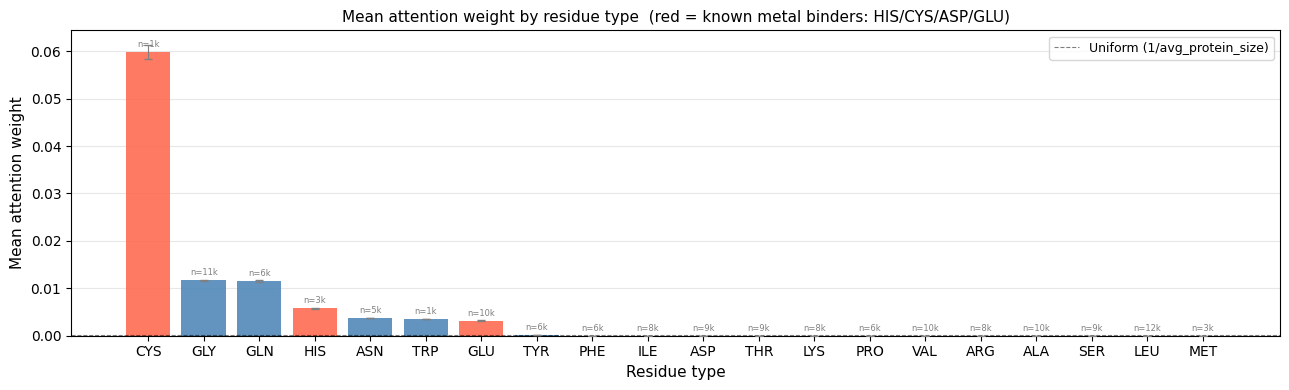


Top 5 residues by mean attention:
  CYS: 0.059824 ← metal binder
  GLY: 0.011694
  GLN: 0.011541
  HIS: 0.005796 ← metal binder
  ASN: 0.003710


In [ ]:
# ── Viz 3: Mean attention weight by residue type ──────────────────────────────
attn_by_res = defaultdict(list)
for r in records:
    for res_idx, w in zip(r['res_type'], r['attn']):
        attn_by_res[IDX_TO_RES[res_idx]].append(w)

mean_attn  = {res: np.mean(ws) for res, ws in attn_by_res.items()}
std_attn   = {res: 1.96 * np.std(ws) / np.sqrt(len(ws)) for res, ws in attn_by_res.items()}

sorted_res = sorted(mean_attn, key=mean_attn.get, reverse=True)

colors = ['tomato' if r in METAL_BINDERS else 'steelblue' for r in sorted_res]
means  = [mean_attn[r] for r in sorted_res]
stds   = [std_attn[r]  for r in sorted_res]
counts = [len(attn_by_res[r]) for r in sorted_res]

fig, ax = plt.subplots(figsize=(13, 4))
bars = ax.bar(sorted_res, means, color=colors, alpha=0.85, zorder=2)
ax.errorbar(sorted_res, means, yerr=stds, fmt='none', color='gray',
            capsize=3, linewidth=0.8, zorder=3)

# Uniform-attention reference line
n_res = len(RESIDUES)
ax.axhline(1.0 / 8682, color='black', linestyle='--', linewidth=0.8, alpha=0.5,
           label='Uniform (1/avg_protein_size)')

ax.set_xlabel('Residue type', fontsize=11)
ax.set_ylabel('Mean attention weight', fontsize=11)
ax.set_title('Mean attention weight by residue type  (red = known metal binders: HIS/CYS/ASP/GLU)',
             fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3, zorder=1)

# Annotate n
for bar, res, n in zip(bars, sorted_res, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(means)*0.01,
            f'n={n//1000}k', ha='center', va='bottom', fontsize=6, color='gray')

plt.tight_layout()
plt.savefig('data/viz_attn_by_res.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 residues by mean attention:')
for res in sorted_res[:5]:
    flag = ' ← metal binder' if res in METAL_BINDERS else ''
    print(f'  {res}: {mean_attn[res]:.6f}{flag}')
